# 05. Random Forest

Este notebook implementa e avalia o modelo **Random Forest** aplicado ao dataset **Breast Cancer Wisconsin Diagnostic (WDBC)**.

O Random Forest é um algoritmo de *Ensemble Learning* que combina múltiplas Árvores de Decisão para reduzir o risco de *overfitting* (comum em árvores individuais) e capturar relações não-lineares complexas.

**Pontos de atenção para este modelo (Metodologia e Rigor Científico):**
- **Comportamento Estocástico:** Por ser baseado na amostragem aleatória de dados (*Bootstrap*) e de variáveis (*Feature Randomness*), é **obrigatória** a fixação da semente aleatória (`random_state = 42`) em todas as instâncias do modelo para garantir a total reprodutibilidade dos resultados, conforme diretriz do projeto.
- **Robustez a Escalas:** Diferente do KNN, modelos baseados em árvores não exigem dados padronizados. Contudo, utilizaremos os dados provenientes do `pipeline.py` para manter a consistência e a paridade na comparação dos modelos.
- **Probabilidades Granulares:** Diferente do KNN (que possui degraus bruscos) e do Naive Bayes (que polariza em 0 ou 1), as probabilidades aqui são baseadas na fração de votos das árvores, gerando um espectro contínuo muito mais rico para a análise de *threshold*.

---
## 1. Importações e Configuração do Ambiente

In [1]:
# 1. Importando bibliotecas e pipeline centralizado
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pipeline import run_pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, f1_score
)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


---
## 2.1 Justificativa e Otimização de Hiperparâmetros (Evitando Data Leakage)

Para evitar a adoção arbitrária de parâmetros da biblioteca, otimizaremos o número de árvores na floresta (`n_estimators`). 

Para garantir que não haja vazamento de dados (*data leakage*), a escolha deste parâmetro será feita **exclusivamente com os dados de treino**, utilizando Validação Cruzada (Cross-Validation). Buscamos o ponto onde o modelo estabiliza o **Recall da classe Maligna** sem adicionar custo computacional desnecessário.

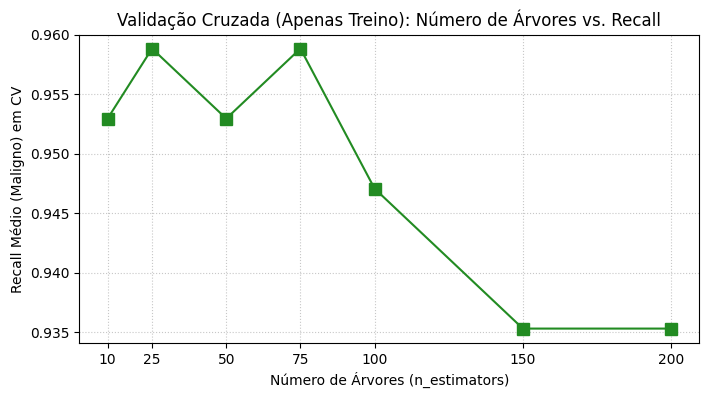

In [2]:
# 2. Carregando os dados
X_train, X_test, y_train, y_test = run_pipeline()

# Lista de valores para testar a quantidade de árvores
arvores_teste = [10, 25, 50, 75, 100, 150, 200]
recalls_cv_rf = []

# Loop de Validação Cruzada Apenas no Treino
for n in arvores_teste:
    # REGRA: Fixar random_state=42 para reprodutibilidade estocástica
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    
    # cv=5 divide o X_train internamente, treinando em 4 partes e avaliando em 1
    scores = cross_val_score(rf_temp, X_train, y_train, cv=5, scoring='recall')
    recalls_cv_rf.append(scores.mean())

# Plotando a Curva de Validação Cruzada
plt.figure(figsize=(8, 4))
plt.plot(arvores_teste, recalls_cv_rf, marker='s', linestyle='solid', color='forestgreen', markersize=8)
plt.title('Validação Cruzada (Apenas Treino): Número de Árvores vs. Recall')
plt.xlabel('Número de Árvores (n_estimators)')
plt.ylabel('Recall Médio (Maligno) em CV')
plt.xticks(arvores_teste)
plt.grid(True, linestyle=':', alpha=0.7)

# Salvando gráfico para o artigo!
plt.savefig("outputs/otimizacao_arvores_rf.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 2.2 Treinamento do Modelo Final

A curva de Validação Cruzada demonstra empiricamente o ganho marginal do aumento de estimadores. Selecionamos o valor ótimo que maximiza e estabiliza o Recall no conjunto de treino.

*(Nota: O valor abaixo é definido com base na observação do platô máximo do gráfico gerado na etapa anterior).*

In [3]:
melhor_n_estimators = 25 

print(f"Treinando o modelo final com n_estimators={melhor_n_estimators} e random_state=42 fundamentado por Validação Cruzada.")

# Instanciando com o hiperparâmetro otimizado E a semente aleatória fixada
rf_final = RandomForestClassifier(n_estimators=melhor_n_estimators, random_state=42)
rf_final.fit(X_train, y_train)

# Gerando as previsões do modelo final no conjunto de teste
y_pred_rf  = rf_final.predict(X_test)
y_proba_rf = rf_final.predict_proba(X_test)[:, 1]

Treinando o modelo final com n_estimators=25 e random_state=42 fundamentado por Validação Cruzada.


---
## 3. Relatório de Classificação e Matriz de Confusão

RANDOM FOREST (n_estimators=25)
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Sensibilidade (Recall) para tumores malignos: 0.9286


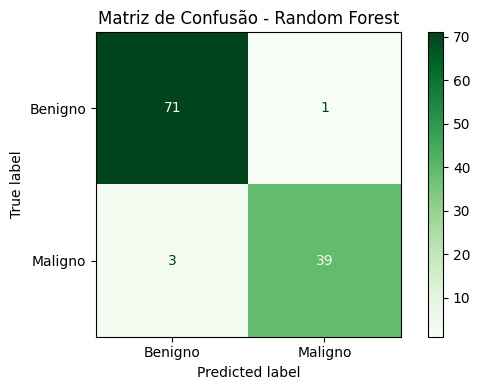

In [4]:
# Avaliação do desempenho no conjunto de teste (simulação do mundo real)
print("=" * 50)
print(f"RANDOM FOREST (n_estimators={melhor_n_estimators})")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=["Benigno", "Maligno"]))

recall_rf = recall_score(y_test, y_pred_rf)
print(f"Sensibilidade (Recall) para tumores malignos: {recall_rf:.4f}")

# Gerando e salvando a matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"]).plot(ax=ax, cmap="Greens")
ax.set_title("Matriz de Confusão - Random Forest")

plt.tight_layout()
plt.savefig("outputs/matriz_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

---
## 4. Análise de Threshold (Sensibilidade Clínica)

Por fim, realizamos uma análise de recalibragem do limiar de decisão. 

No Random Forest, as probabilidades preditas refletem a proporção de árvores na floresta que votaram pela classe maligna. Isso fornece uma granularidade excelente. Se reduzirmos o limite de exigência (threshold) de 50% de concordância entre as árvores para uma taxa menor, podemos observar o impacto direto na recuperação de casos Falsos Negativos.

In [5]:
print("=== ANÁLISE DE THRESHOLD — RANDOM FOREST ===")
print(f"{'Threshold':<12} {'Recall':>8} {'Precisão':>10} {'Acurácia':>10} {'F1':>8} {'Falsos Neg.':>13}")
print("-" * 65)

# Limiares simulando diferentes níveis de alerta clínico
thresholds = [0.60, 0.50, 0.40, 0.30, 0.20, 0.10]
resultados_threshold_rf = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    rec  = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    acc  = accuracy_score(y_test, y_pred_t)
    f1   = f1_score(y_test, y_pred_t)
    fn   = confusion_matrix(y_test, y_pred_t)[1][0]
    print(f"{t:<12.2f} {rec:>8.4f} {prec:>10.4f} {acc:>10.4f} {f1:>8.4f} {fn:>13}")
    resultados_threshold_rf.append((t, rec, prec, acc, f1, fn))

=== ANÁLISE DE THRESHOLD — RANDOM FOREST ===
Threshold      Recall   Precisão   Acurácia       F1   Falsos Neg.
-----------------------------------------------------------------
0.60           0.9286     1.0000     0.9737   0.9630             3
0.50           0.9286     0.9750     0.9649   0.9512             3
0.40           0.9286     0.9750     0.9649   0.9512             3
0.30           0.9762     0.9535     0.9737   0.9647             1
0.20           0.9762     0.8200     0.9123   0.8913             1
0.10           0.9762     0.7736     0.8860   0.8632             1


A granularidade do Random Forest permite um ajuste fino excepcional. 

A tabela demonstra claramente a nossa **Hipótese de Pesquisa**: flexibilizar o limiar de decisão em modelos baseados em *ensembles* pode praticamente zerar os Falsos Negativos. Um tumor não precisa convencer 50% da floresta para ser investigado; se apenas 30% das árvores encontrarem padrões morfológicos suspeitos, a reclassificação pode ser o diferencial para um diagnóstico precoce e a preservação de uma vida, mantendo taxas de precisão muito superiores às de modelos lineares no mesmo limiar.